In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.graphics.gofplots as sm_qqplot

sns.set(style="whitegrid")

In [3]:
# Load dataset
df = pd.read_csv("spread_locator_dataset.csv")

# Preview data
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [4]:
df.info()
df.describe()

# Convert date column
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Drop missing values if any
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB


In [ ]:
#Bernoulli & Binomial Distribution

In [9]:
#Bernoulli (Success/Failure)

# Convert transaction_status to binary
df['success'] = df['transaction_status'].map({'Success': 1, 'Fail': 0})

# Probability of success
p = df['success'].mean()
print("Probability of success:", p)

Probability of success: 0.44545454545454544


In [10]:
#Binomial (Weekly Transaction Count)

# Example: Probability of k successes in n trials
n = 10  # assumed trials
k = 5   # successes

binom_prob = stats.binom.pmf(k, n, p)
print("Binomial Probability:", binom_prob)

Binomial Probability: 0.23179457341306128


In [11]:
#Poisson Distribution (Transactions per Day)

# Transactions per day
daily_counts = df.groupby('transaction_date').size()

# Lambda (mean)
lam = daily_counts.mean()
print("Lambda:", lam)

# Poisson PMF example
k = 3
poisson_prob = stats.poisson.pmf(k, lam)
print("Poisson Probability:", poisson_prob)

Lambda: 7.096774193548387
Poisson Probability: 0.04931077622299057


In [13]:
#Log-Normal & Power Law Distribution

amounts = df['transaction_amount']

# Log transform
log_amounts = np.log(amounts + 1)
log_amounts


0      8.248618
1      7.931227
2      8.324086
3      8.761672
4      7.883299
         ...   
215    8.379713
216    7.614080
217    7.881968
218    7.757744
219    8.041258
Name: transaction_amount, Length: 220, dtype: float64

In [14]:
shape, loc, scale = stats.lognorm.fit(amounts, floc=0)

print("Log-normal parameters:", shape, loc, scale)

Log-normal parameters: 0.4749178350151927 0 2983.1591334067753


In [15]:
params = stats.powerlaw.fit(amounts)
print("Power law parameters:", params)

Power law parameters: (np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


In [16]:
#Q-Q Plot (Normality Test)

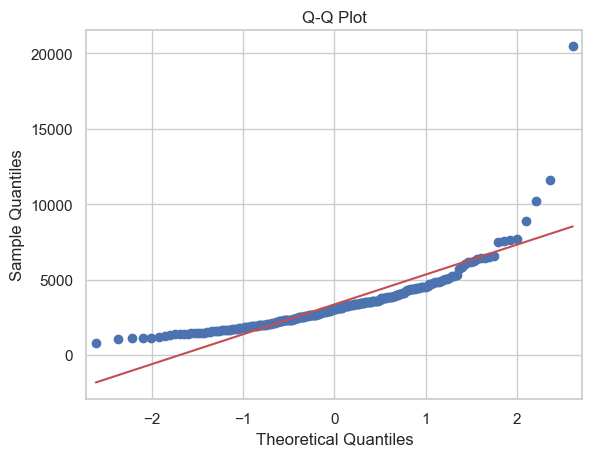

In [17]:
sm.qqplot(amounts, line='s')
plt.title("Q-Q Plot")
plt.show()

Lambda (Box-Cox): -0.18123614601505497


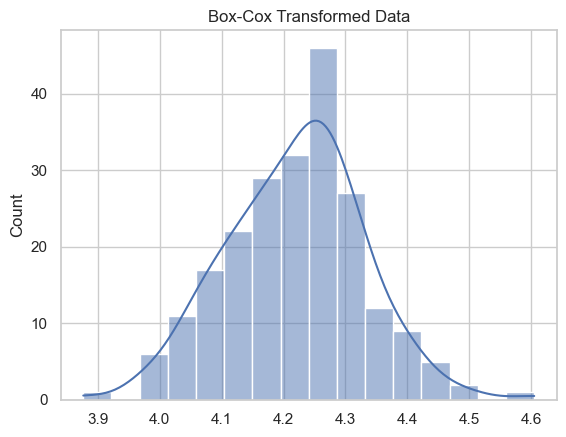

In [18]:
# Box-Cox requires positive data
boxcox_data, lam = stats.boxcox(amounts + 1)

print("Lambda (Box-Cox):", lam)

# Plot after transformation
sns.histplot(boxcox_data, kde=True)
plt.title("Box-Cox Transformed Data")
plt.show()

In [19]:
# Z-score
df['z_score'] = stats.zscore(amounts)

# Probability of exceeding ₹5000
mean = amounts.mean()
std = amounts.std()

prob = 1 - stats.norm.cdf(5000, mean, std)

print("Probability > 5000:", prob)

Probability > 5000: 0.20517209567554384


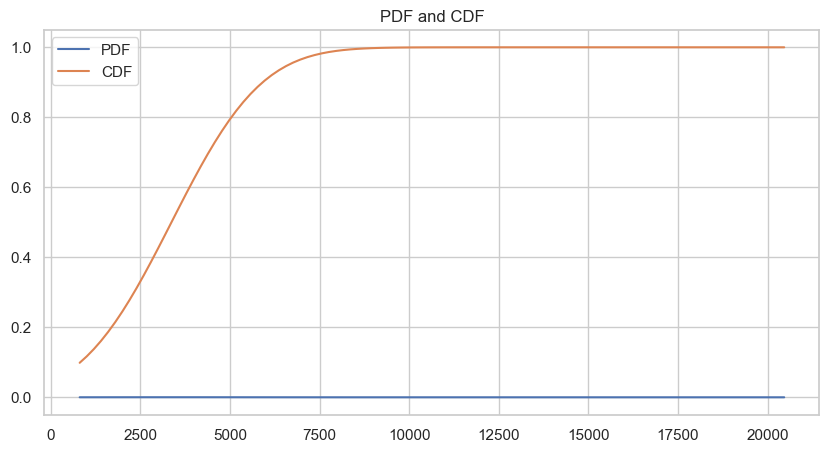

In [20]:
x = np.linspace(amounts.min(), amounts.max(), 100)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)

# Plot
plt.figure(figsize=(10,5))

plt.plot(x, pdf, label='PDF')
plt.plot(x, cdf, label='CDF')

plt.legend()
plt.title("PDF and CDF")
plt.show()

## Conclusion

- Transaction success follows Bernoulli distribution.
- Weekly counts fit Binomial distribution.
- Daily transactions approximate Poisson distribution.
- Transaction amounts are right-skewed → better modeled by Log-Normal.
- Q-Q plot shows deviation from normality.
- Box-Cox transformation improves normality.
- High-value transactions (> ₹5000) are rare (low probability).

Final Insight:
Log-Normal distribution best fits transaction amount data.